In [12]:
%pip install torch numpy pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Bitcoin Price Prediction with RNN and Bidirectional RNN (PyTorch)
This notebook reads the Kaggle dataset `btcusd_1-min_data.csv`, preprocesses it by resampling to daily frequencies, and trains an RNN and a Bidirectional RNN model to predict the Close price.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import os

import warnings
warnings.filterwarnings('ignore')

In [14]:
csv_file = "btcusd_1-min_data.csv"
if not os.path.exists(csv_file):
    print(f"Error: {csv_file} not found.\nPlease download from Kaggle and place it in the same directory.")
else:
    print("Loading dataset...")
    df = pd.read_csv(csv_file)
    print(df.head())

Loading dataset...
      Timestamp  Open  High   Low  Close  Volume
0  1.325412e+09  4.58  4.58  4.58   4.58     0.0
1  1.325412e+09  4.58  4.58  4.58   4.58     0.0
2  1.325412e+09  4.58  4.58  4.58   4.58     0.0
3  1.325412e+09  4.58  4.58  4.58   4.58     0.0
4  1.325412e+09  4.58  4.58  4.58   4.58     0.0


In [15]:
if os.path.exists(csv_file):
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')
    df.set_index('Timestamp', inplace=True)
    
    df_daily = df.resample('D').mean()
    df_daily.fillna(method='ffill', inplace=True)
    
    data = df_daily[['Close']].values
    print("Data shape after resampling:", data.shape)
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)


Data shape after resampling: (5254, 1)


In [16]:
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

if os.path.exists(csv_file):
    seq_length = 60
    X, y = create_sequences(scaled_data, seq_length)
    
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    # Reshape for PyTorch [samples, time steps, features]
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
    
    # Convert to PyTorch tensors
    X_train_tensor = torch.Tensor(X_train)
    y_train_tensor = torch.Tensor(y_train).view(-1, 1)
    X_test_tensor = torch.Tensor(X_test)
    y_test_tensor = torch.Tensor(y_test).view(-1, 1)
    
    train_data = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_data, batch_size=64, shuffle=False)
    print("X_train shape:", X_train.shape)

X_train shape: (4155, 60, 1)


## 1. Simple RNN Model (PyTorch)

In [17]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2):
        super(SimpleRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

if os.path.exists(csv_file):
    rnn_model = SimpleRNN()
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.001)
    
    print("Training Simple RNN...")
    epochs = 10
    for epoch in range(epochs):
        rnn_model.train()
        epoch_loss = 0
        for seq, labels in train_loader:
            optimizer.zero_grad()
            outputs = rnn_model(seq)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}')

Training Simple RNN...
Epoch 1/10, Loss: 0.0102
Epoch 2/10, Loss: 0.0116
Epoch 3/10, Loss: 0.0154
Epoch 4/10, Loss: 0.0135
Epoch 5/10, Loss: 0.0139
Epoch 6/10, Loss: 0.0124
Epoch 7/10, Loss: 0.0104
Epoch 8/10, Loss: 0.0055
Epoch 9/10, Loss: 0.0018
Epoch 10/10, Loss: 0.0007


## 2. Bidirectional RNN Model (PyTorch)

In [18]:
class BiLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2):
        super(BiLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size * 2, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

if os.path.exists(csv_file):
    bi_model = BiLSTM()
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(bi_model.parameters(), lr=0.001)
    
    print("Training Bidirectional LSTM...")
    epochs = 10
    for epoch in range(epochs):
        bi_model.train()
        epoch_loss = 0
        for seq, labels in train_loader:
            optimizer.zero_grad()
            outputs = bi_model(seq)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}')

Training Bidirectional LSTM...
Epoch 1/10, Loss: 0.0094
Epoch 2/10, Loss: 0.0194
Epoch 3/10, Loss: 0.0196
Epoch 4/10, Loss: 0.0170
Epoch 5/10, Loss: 0.0121
Epoch 6/10, Loss: 0.0088
Epoch 7/10, Loss: 0.0037
Epoch 8/10, Loss: 0.0013
Epoch 9/10, Loss: 0.0007
Epoch 10/10, Loss: 0.0006


## 3. Evaluation & Comparison

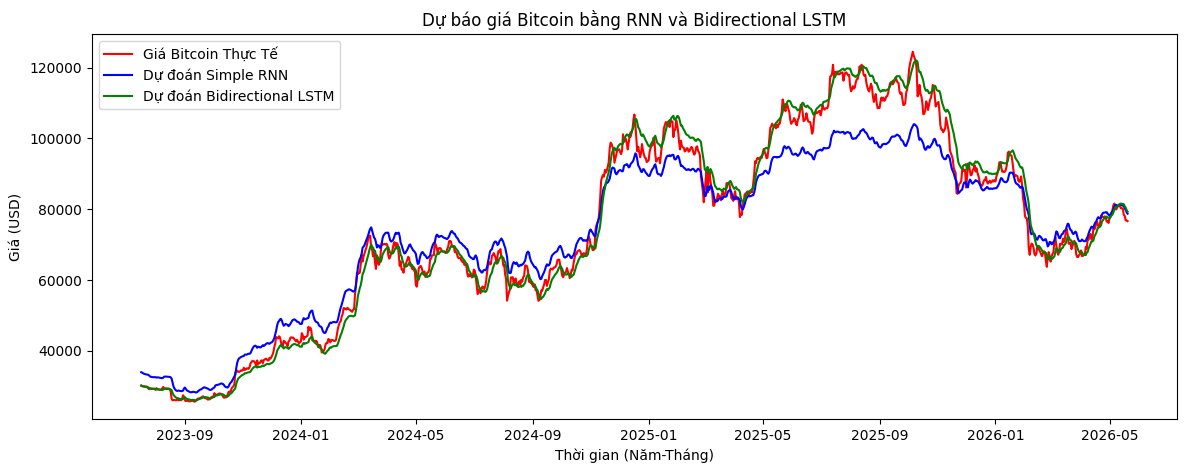

In [21]:
if os.path.exists(csv_file):
    rnn_model.eval()
    bi_model.eval()
    
    with torch.no_grad():
        rnn_preds = rnn_model(X_test_tensor).numpy()
        bi_preds = bi_model(X_test_tensor).numpy()
    
    # Scale ngược lại giá trị gốc
    rnn_predictions = scaler.inverse_transform(rnn_preds)
    bi_predictions = scaler.inverse_transform(bi_preds)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
    
    # --- PHẦN THÊM VÀO ĐỂ LẤY NGÀY THÁNG ---
    # Lấy các mốc ngày tháng tương ứng với tập Test
    # (Bỏ qua 60 ngày đầu tiên dùng làm sequence và phần dữ liệu Train)
    test_dates = df_daily.index[seq_length + train_size:]
    
    # Vẽ biểu đồ với test_dates làm trục X
    plt.figure(figsize=(14,5))
    plt.plot(test_dates, y_test_inv, color='red', label='Giá Bitcoin Thực Tế')
    plt.plot(test_dates, rnn_predictions, color='blue', label='Dự đoán Simple RNN')
    plt.plot(test_dates, bi_predictions, color='green', label='Dự đoán Bidirectional LSTM')
    plt.title('Dự báo giá Bitcoin bằng RNN và Bidirectional LSTM')
    plt.xlabel('Thời gian (Năm-Tháng)')
    plt.ylabel('Giá (USD)')
    plt.legend()
    plt.show()